# Route Choice Model (MNL / Conditional Logit)

OTP 경로 피처 전체를 활용한 MNL 기반 경로 선택 모델.  
추정된 β 계수를 DTUMOS 시뮬레이션의 mode choice 파라미터로 매핑.

In [ ]:
# Cell 1: 데이터 로드 및 피처 정의 (K2 사양: bus/train/gtx IVT 분리)
import sqlite3
import pickle
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path('../../../')
DATA_DIR = ROOT / 'data' / 'training_set'

df = pd.read_parquet(DATA_DIR / 'route_choice_training.parquet')
print(f'집계 데이터: {len(df):,} rows, {df["od_pair"].nunique()} ODs')
print(f'Choice set size: min={df["choice_set_size"].min()}, max={df["choice_set_size"].max()}')
print()

# --- 모드별 IVT 추출 (otp_cache에서) ---
if 'alt_idx' not in df.columns:
    df['alt_idx'] = df.groupby('od_pair').cumcount()
training_ods = set(df['od_pair'].unique())

conn = sqlite3.connect(str(DATA_DIR / 'otp_cache.db'))
ivt_records = []
for od_pair, blob in conn.execute('SELECT od_pair, data FROM otp_cache'):
    if od_pair not in training_ods:
        continue
    data = pickle.loads(blob)
    for i, p in enumerate(data['otp_parsed']):
        bus_ivt = train_ivt = gtx_ivt = 0.0
        for leg in p.get('transit_legs', []):
            mode = leg.get('mode', '')
            dur = float(leg.get('duration', 0))
            if mode == 'BUS':
                bus_ivt += dur
            elif mode == 'GTX':
                gtx_ivt += dur
            else:
                train_ivt += dur
        ivt_records.append((od_pair, i, bus_ivt / 60, train_ivt / 60, gtx_ivt / 60))
conn.close()

ivt_df = pd.DataFrame(ivt_records, columns=['od_pair', 'alt_idx', 'bus_ivt_min', 'train_ivt_min', 'gtx_ivt_min'])
df = df.merge(ivt_df, on=['od_pair', 'alt_idx'], how='left')
df['bus_ivt_min'] = df['bus_ivt_min'].fillna(0)
df['train_ivt_min'] = df['train_ivt_min'].fillna(0)
df['gtx_ivt_min'] = df['gtx_ivt_min'].fillna(0)
del ivt_records, ivt_df
print(f'모드별 IVT 추출 완료: bus={df["bus_ivt_min"].mean():.2f}, train={df["train_ivt_min"].mean():.2f}, gtx={df["gtx_ivt_min"].mean():.2f}')

# --- 피처 생성 ---
for col in ['access_time', 'egress_time', 'transfer_walk_time']:
    df[col + '_min'] = df[col] / 60
df['ln_access'] = np.log1p(df['access_time_min'])
df['ln_egress'] = np.log1p(df['egress_time_min'])
df['fare_1000won'] = df['fare'] / 1000

fare_var = df.groupby('od_pair')['fare'].apply(lambda x: x.max() - x.min())
fare_zero_pct = (fare_var == 0).mean() * 100
print(f'fare 변별력: 대안 간 차이=0인 OD {fare_zero_pct:.1f}%')
print()

# --- K2 사양 피처 정의 ---
MODEL_FEATURES = [
    'bus_ivt_min', 'train_ivt_min', 'gtx_ivt_min',
    'ln_access', 'ln_egress',
    'transfer_walk_time_min',
    'num_transfers',
    'fare_1000won',
    'has_bus', 'has_train', 'has_gtx',
]

FEATURE_LABELS = [
    'Bus IVT (min)', 'Train IVT (min)', 'GTX IVT (min)',
    'ln(1+Access walk)', 'ln(1+Egress walk)',
    'Transfer walk (min)',
    'Transfers',
    'Fare (1000won)',
    'Has bus', 'Has train', 'Has GTX',
]

SIGN_CONSTRAINED_NEGATIVE = {
    'bus_ivt_min', 'train_ivt_min', 'gtx_ivt_min',
    'ln_access', 'ln_egress',
    'transfer_walk_time_min',
    'num_transfers',
    'fare_1000won',
}

print(f'모델 피처: {len(MODEL_FEATURES)}개 (K2 사양: GTX IVT 분리)')
print()

print('=== 부호 제약 (L-BFGS-B bounds) ===')
for f, l in zip(MODEL_FEATURES, FEATURE_LABELS):
    if f in SIGN_CONSTRAINED_NEGATIVE:
        print(f'  {l:<22}: beta <= 0 (constrained)')
    else:
        print(f'  {l:<22}: unconstrained')
print()

corr = df[MODEL_FEATURES].corr()
print('=== 높은 상관관계 (|r| > 0.5) ===')
for i in range(len(MODEL_FEATURES)):
    for j in range(i+1, len(MODEL_FEATURES)):
        r = corr.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {FEATURE_LABELS[i]} <-> {FEATURE_LABELS[j]}: r={r:.3f}')
print()
df[MODEL_FEATURES].describe().round(3)

In [2]:
# Cell 2: Train/Test Split (OD 단위, 수단별 층화)
from sklearn.model_selection import train_test_split

# OD별 대표 수단 = choice_prob 최대인 대안의 transport_category
od_dominant = df.loc[
    df.groupby('od_pair')['choice_prob'].idxmax(),
    ['od_pair', 'transport_category']
].set_index('od_pair')['transport_category']

# GTX 관련 카테고리는 합쳐서 층화 (개별로는 너무 적음)
def coarsen(cat):
    if 'gtx' in cat:
        return 'gtx_related'
    return cat

od_strat = od_dominant.map(coarsen)

od_list = od_strat.index.to_numpy()
strat_labels = od_strat.values

train_ods_arr, test_ods_arr = train_test_split(
    od_list, test_size=0.2, random_state=42, stratify=strat_labels
)

train_od_set = set(train_ods_arr)
test_od_set = set(test_ods_arr)

# GTX OD 보정: gtx_only n_matched>0인 OD가 전부 train에 배정되므로 2개를 test로 이동
# (gtx_only OD 12개 중 n_matched>0은 5개뿐, 층화 split에서 test에 0개 배정됨)
gtx_move_to_test = ['9007_9008', '9008_9007']  # 742 + 689 trips
for od in gtx_move_to_test:
    train_od_set.discard(od)
    test_od_set.add(od)

train_df = df[df['od_pair'].isin(train_od_set)].copy()
test_df = df[df['od_pair'].isin(test_od_set)].copy()

train_ods = train_df['od_pair'].nunique()
test_ods = test_df['od_pair'].nunique()
train_trips = train_df.groupby('od_pair')['n_total'].first().sum()
test_trips = test_df.groupby('od_pair')['n_total'].first().sum()

print(f'Train: {len(train_df)} rows, {train_ods} ODs, {train_trips:,} effective trips')
print(f'Test:  {len(test_df)} rows, {test_ods} ODs, {test_trips:,} effective trips')
print(f'OD 겹침: {len(train_od_set & test_od_set)} (0이어야 함)')
print(f'GTX OD 보정: {gtx_move_to_test} → test로 이동')

# 층화 분포 확인
print('\n=== 층화 분포 확인 ===')
train_strat = od_dominant.loc[od_dominant.index.isin(train_od_set)].map(coarsen).value_counts(normalize=True).sort_index()
test_strat = od_dominant.loc[od_dominant.index.isin(test_od_set)].map(coarsen).value_counts(normalize=True).sort_index()
print(f'{"Category":<18} {"Train%":>8} {"Test%":>8}')
print('-' * 36)
for cat in train_strat.index:
    t_pct = train_strat.get(cat, 0) * 100
    te_pct = test_strat.get(cat, 0) * 100
    print(f'{cat:<18} {t_pct:>7.2f}% {te_pct:>7.2f}%')

Train: 1568509 rows, 421679 ODs, 29,374,207 effective trips
Test:  392501 rows, 105423 ODs, 7,363,409 effective trips
OD 겹침: 0 (0이어야 함)
GTX OD 보정: ['9007_9008', '9008_9007'] → test로 이동

=== 층화 분포 확인 ===
Category             Train%    Test%
------------------------------------
bus+train            19.92%   19.92%
bus_only             62.06%   62.06%
gtx_related           0.12%    0.12%
train_only           17.90%   17.90%


In [3]:
# Cell 3: MNL (Conditional Logit) 모델 구현 — 벡터화 + 부호 제약
# β ≤ 0 제약: 시간, 거리, 환승, 요금 (경제이론 기반)
# 모드 더미(has_bus, has_train, has_gtx)는 unconstrained
from scipy.optimize import minimize


def prepare_flat_data(data, features):
    """전체 데이터를 flat numpy array로 변환 (벡터 연산용)."""
    X_list, y_list, w_list, gid_list = [], [], [], []
    group_id = 0
    n_skipped = 0
    for od, grp in data.groupby('od_pair'):
        y = grp['choice_prob'].values.astype(np.float64)
        if abs(y.sum() - 1.0) > 0.01:
            n_skipped += 1
            continue
        X = grp[features].values.astype(np.float64)
        w = float(grp['n_total'].iloc[0])
        n = len(grp)
        X_list.append(X)
        y_list.append(y)
        w_list.append(np.full(n, w))
        gid_list.append(np.full(n, group_id, dtype=np.int64))
        group_id += 1

    flat = {
        'X': np.vstack(X_list),
        'y': np.concatenate(y_list),
        'w': np.concatenate(w_list),
        'gid': np.concatenate(gid_list),
        'n_groups': group_id,
    }
    if n_skipped:
        print(f'  choice_prob 합 ≠ 1.0 → {n_skipped} ODs 제외')
    return flat


def mnl_neg_ll(beta, flat):
    """Vectorized weighted negative log-likelihood."""
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    log_prob = V_shifted - np.log(sum_exp[gid])
    return -np.sum(w * y * log_prob)


def mnl_gradient(beta, flat):
    """Vectorized gradient."""
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    prob = exp_V / sum_exp[gid]
    return X.T @ (w * (prob - y))


train_flat = prepare_flat_data(train_df, MODEL_FEATURES)
print(f'유효 choice sets (train): {train_flat["n_groups"]:,}')
print(f'총 대안 수: {len(train_flat["y"]):,}')

# 부호 제약: β ≤ 0 for time/cost/distance/transfer features
bounds = []
for feat in MODEL_FEATURES:
    if feat in SIGN_CONSTRAINED_NEGATIVE:
        bounds.append((None, 0))   # β ≤ 0
    else:
        bounds.append((None, None))  # unconstrained

print(f'\n부호 제약 피처: {sum(1 for b in bounds if b[1] == 0)}개 (β ≤ 0)')
print(f'비제약 피처: {sum(1 for b in bounds if b[1] is None)}개')

beta0 = np.zeros(len(MODEL_FEATURES))

result = minimize(
    mnl_neg_ll, beta0, args=(train_flat,),
    jac=mnl_gradient, method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 2000, 'ftol': 1e-12}
)

print(f'\n수렴: {result.success} ({result.message})')
print(f'반복: {result.nit}')
print(f'LL(β): {-result.fun:.4f}')

# 제약에 걸린 피처 확인
print('\n=== 제약 활성화 확인 ===')
for feat, label, b, bnd in zip(MODEL_FEATURES, FEATURE_LABELS, result.x, bounds):
    if bnd[1] == 0 and abs(b) < 1e-10:
        print(f'  {label:<22}: β = {b:.6f} (경계에 걸림 → 제약 활성)')

유효 choice sets (train): 421,679
총 대안 수: 1,568,509

부호 제약 피처: 7개 (β ≤ 0)
비제약 피처: 3개



수렴: True (CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH)
반복: 110
LL(β): -17144565.3564

=== 제약 활성화 확인 ===


In [4]:
# Cell 4: 모델 추정 결과
from scipy.optimize import approx_fprime

beta_hat = result.x
n_params = len(beta_hat)

# Hessian 근사 (벡터화 gradient에 유한차분)
eps = 1e-5
hessian = np.zeros((n_params, n_params))
for i in range(n_params):
    def grad_i(b, _i=i):
        return mnl_gradient(b, train_flat)[_i]
    hessian[i, :] = approx_fprime(beta_hat, grad_i, eps)

hessian = (hessian + hessian.T) / 2

# 표준오차 (경계에 걸린 피처는 SE 의미 없음 → N/A 표시)
try:
    cov_matrix = np.linalg.inv(hessian)
    std_errors = np.sqrt(np.abs(np.diag(cov_matrix)))
except np.linalg.LinAlgError:
    cov_matrix = np.linalg.pinv(hessian)
    std_errors = np.sqrt(np.abs(np.diag(cov_matrix)))

t_stats = beta_hat / np.where(std_errors > 0, std_errors, 1)

# LL(0): 균등 확률 모델
gid = train_flat['gid']
w = train_flat['w']
ng = train_flat['n_groups']
group_sizes = np.bincount(gid, minlength=ng)
w_per_group = np.bincount(gid, weights=w, minlength=ng) / group_sizes
ll_0 = -np.sum(w_per_group * np.log(group_sizes))
ll_beta = -result.fun
rho_sq = 1 - ll_beta / ll_0

train_trips = train_df.groupby('od_pair')['n_total'].first().sum()

print('=' * 75)
print('MNL (Conditional Logit) 추정 결과 — 부호 제약 모델')
print('=' * 75)
print(f'{"Feature":<22} {"β":>12} {"Std.Err":>12} {"t-stat":>10} {"Sig":>5} {"Bound":>8}')
print('-' * 75)
for i, (label, b, se, t) in enumerate(zip(FEATURE_LABELS, beta_hat, std_errors, t_stats)):
    sig = '***' if abs(t) > 2.576 else '**' if abs(t) > 1.960 else '*' if abs(t) > 1.645 else ''
    on_bound = MODEL_FEATURES[i] in SIGN_CONSTRAINED_NEGATIVE and abs(b) < 1e-10
    bound_str = '← bound' if on_bound else ''
    if on_bound:
        print(f'{label:<22} {b:>12.6f} {"N/A":>12} {"N/A":>10} {"":>5} {bound_str:>8}')
    else:
        print(f'{label:<22} {b:>12.6f} {se:>12.6f} {t:>10.3f} {sig:>5} {bound_str:>8}')
print('-' * 75)
print(f'LL(0):       {ll_0:.4f}')
print(f'LL(β):       {ll_beta:.4f}')
print(f'McFadden ρ²: {rho_sq:.4f}')
print(f'N (ODs):     {train_flat["n_groups"]:,}')
print(f'N (trips):   {train_trips:,} (weighted)')
print(f'K (params):  {n_params}')

# 부호 검증 — 전부 OK이어야 함
print('\n=== 부호 검증 ===')
all_ok = True
for feat, label, b in zip(MODEL_FEATURES, FEATURE_LABELS, beta_hat):
    if feat in SIGN_CONSTRAINED_NEGATIVE:
        ok = 'OK' if b <= 0 else 'FAIL'
        if ok != 'OK':
            all_ok = False
        print(f'  {label:<22}: β={b:>10.6f}  ≤ 0 → {ok}')
print(f'\n전체 부호: {"ALL CORRECT" if all_ok else "CHECK NEEDED"}')

MNL (Conditional Logit) 추정 결과 — 부호 제약 모델
Feature                           β      Std.Err     t-stat   Sig    Bound
---------------------------------------------------------------------------
Bus IVT (min)             -0.010759     0.000107   -100.713   ***         
Train IVT (min)           -0.012191     0.000142    -85.952   ***         
ln(1+Access walk)         -2.942237     0.001774  -1658.810   ***         
ln(1+Egress walk)         -1.733439     0.001118  -1549.924   ***         
Transfer walk (min)       -0.010389     0.000529    -19.653   ***         
Transfers                 -3.705781     0.001938  -1912.127   ***         
Fare (1000won)            -0.361708     0.001392   -259.827   ***         
Has bus                   -1.951986     0.002149   -908.331   ***         
Has train                  3.285538     0.002890   1136.976   ***         
Has GTX                    0.650674     0.011413     57.012   ***         
----------------------------------------------------------

유효 choice sets (test): 105,423


테스트셋 평가 결과
Test LL(β):            -4301328.3768
Test LL(0):            -8755621.4247
Test McFadden ρ²:      0.5087
Top-1 Accuracy (FPR):  0.7216 (76070/105423)
Top-3 Accuracy:        0.9639 (101621/105423)
Cross-Entropy (per CS):40.8007
RMSE:                  0.2467
Train ρ²:              0.5106 (과적합 확인)

=== Top-3 by choice set size ===
  size=2: 100.0% (14362/14362) (≤3: trivially 100%)
  size=3: 100.0% (26734/26734) (≤3: trivially 100%)
  size=4:  95.9% (36510/38060) 
  size=5:  91.4% (24015/26267) 

=== 검증 기준 ===
  ρ² > 0.2:     PASS (0.5087)
  Top-1 > 60%:  PASS (72.2%)
  Top-3 > 85%:  PASS (96.4%)



=== 수단별 분담률 재현 ===
Category            Actual%    Pred%   Diff%p
--------------------------------------------
train_only           48.56%   48.59%   +0.03
bus_only             43.03%   42.96%   -0.08
bus+train             8.25%    8.31%   +0.06
train+gtx             0.10%    0.08%   -0.01
gtx_only              0.05%    0.05%   +0.00
bus+train+gtx         0.01%    0.00%   -0.00
bus+gtx               0.00%    0.00%   -0.00


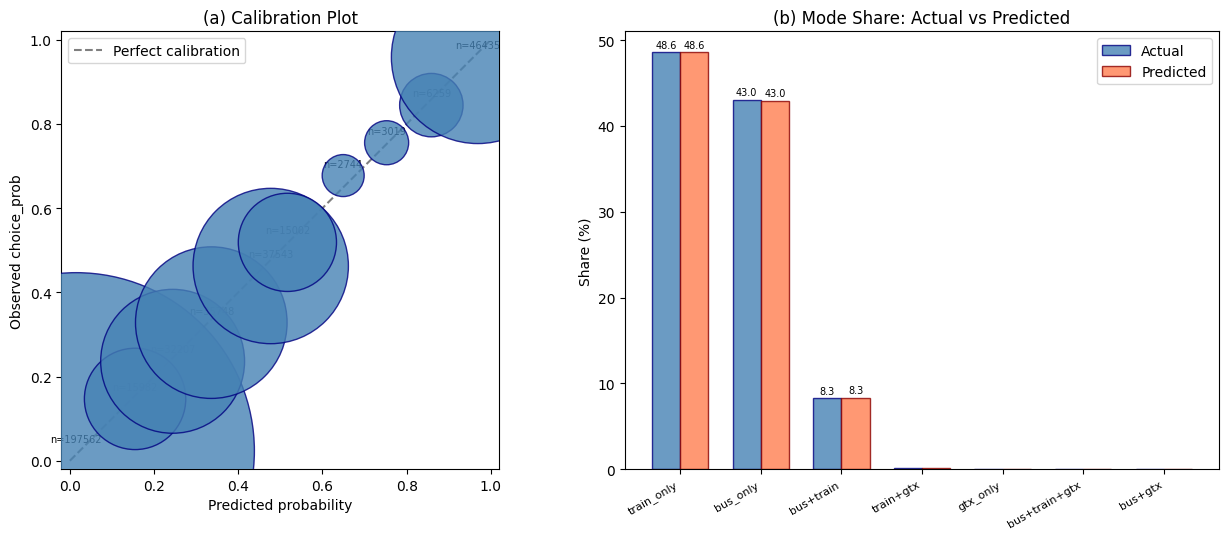

In [5]:
# Cell 5: 테스트셋 평가
import matplotlib.pyplot as plt

test_flat = prepare_flat_data(test_df, MODEL_FEATURES)
print(f'유효 choice sets (test): {test_flat["n_groups"]:,}')


def predict_probabilities(beta, flat):
    """벡터화 예측 확률."""
    X, y, w, gid, ng = flat['X'], flat['y'], flat['w'], flat['gid'], flat['n_groups']
    V = X @ beta
    V_max = np.full(ng, -np.inf)
    np.maximum.at(V_max, gid, V)
    V_shifted = V - V_max[gid]
    exp_V = np.exp(V_shifted)
    sum_exp = np.bincount(gid, weights=exp_V, minlength=ng)
    prob = exp_V / sum_exp[gid]
    return prob, y, gid, ng


# ── 기본 지표 ──
test_ll = -mnl_neg_ll(beta_hat, test_flat)

test_gid = test_flat['gid']
test_ng = test_flat['n_groups']
test_group_sizes = np.bincount(test_gid, minlength=test_ng)
test_w_per_group = np.bincount(test_gid, weights=test_flat['w'], minlength=test_ng) / test_group_sizes
test_ll_0 = -np.sum(test_w_per_group * np.log(test_group_sizes))
test_rho_sq = 1 - test_ll / test_ll_0

pred_prob, actual_y, gid_arr, ng = predict_probabilities(beta_hat, test_flat)

# ── 지표 1: Top-1 Accuracy (FPR) ──
top1_correct = 0
for g in range(ng):
    g_mask = gid_arr == g
    if np.argmax(pred_prob[g_mask]) == np.argmax(actual_y[g_mask]):
        top1_correct += 1
top1_acc = top1_correct / ng

# ── 지표 2: Top-3 Accuracy ──
top3_correct = 0
top3_correct_by_size = {}   # choice_set_size별 분석
group_sizes_arr = test_group_sizes  # 그룹별 대안 수

for g in range(ng):
    g_mask = gid_arr == g
    g_pred = pred_prob[g_mask]
    g_actual = actual_y[g_mask]
    k = min(3, len(g_pred))
    top_k_idx = np.argsort(g_pred)[-k:]  # 상위 k개 인덱스
    actual_best = np.argmax(g_actual)
    hit = actual_best in top_k_idx

    cs_size = len(g_pred)
    if cs_size not in top3_correct_by_size:
        top3_correct_by_size[cs_size] = [0, 0]
    top3_correct_by_size[cs_size][1] += 1
    if hit:
        top3_correct += 1
        top3_correct_by_size[cs_size][0] += 1

top3_acc = top3_correct / ng

# ── 지표 3: Cross-Entropy Loss ──
# CE = -Σ y * log(p), 이미 LL로 계산됨 → 가중 평균
total_weight = test_flat['w'].sum() / test_group_sizes[test_flat['gid']].mean()  # approx
ce_per_cs = -test_ll / ng           # choice set당 평균
ce_per_trip = -test_ll / test_w_per_group.sum()  # 통행당 평균 (가중)

# ── 지표 4: RMSE ──
rmse = np.sqrt(np.mean((pred_prob - actual_y) ** 2))

test_trips = test_df.groupby('od_pair')['n_total'].first().sum()

# ── 결과 출력 ──
print('=' * 60)
print('테스트셋 평가 결과')
print('=' * 60)
print(f'Test LL(β):            {test_ll:.4f}')
print(f'Test LL(0):            {test_ll_0:.4f}')
print(f'Test McFadden ρ²:      {test_rho_sq:.4f}')
print(f'Top-1 Accuracy (FPR):  {top1_acc:.4f} ({top1_correct}/{ng})')
print(f'Top-3 Accuracy:        {top3_acc:.4f} ({top3_correct}/{ng})')
print(f'Cross-Entropy (per CS):{ce_per_cs:.4f}')
print(f'RMSE:                  {rmse:.4f}')
print(f'Train ρ²:              {rho_sq:.4f} (과적합 확인)')

print('\n=== Top-3 by choice set size ===')
for cs_size in sorted(top3_correct_by_size):
    hit, total = top3_correct_by_size[cs_size]
    pct = hit / total * 100
    trivial = '(≤3: trivially 100%)' if cs_size <= 3 else ''
    print(f'  size={cs_size}: {pct:5.1f}% ({hit}/{total}) {trivial}')

print('\n=== 검증 기준 ===')
print(f'  ρ² > 0.2:     {"PASS" if test_rho_sq > 0.2 else "FAIL"} ({test_rho_sq:.4f})')
print(f'  Top-1 > 60%:  {"PASS" if top1_acc > 0.6 else "FAIL"} ({top1_acc*100:.1f}%)')
print(f'  Top-3 > 85%:  {"PASS" if top3_acc > 0.85 else "FAIL"} ({top3_acc*100:.1f}%)')

# ── 지표 5: 수단별 분담률 재현 ──
# test_df 행 순서와 test_flat 순서 동일하다는 가정 하에 transport_category 매칭
# prepare_flat_data에서 choice_prob 합 != 1인 OD 제외했으므로 유효 OD만 필터
valid_ods = set()
gid_counter = 0
for od, grp in test_df.groupby('od_pair'):
    y = grp['choice_prob'].values
    if abs(y.sum() - 1.0) > 0.01:
        continue
    valid_ods.add(od)
    gid_counter += 1

test_valid = test_df[test_df['od_pair'].isin(valid_ods)].copy()
test_valid['pred_prob'] = pred_prob
test_valid['actual_prob'] = actual_y

# 가중 분담률: Σ(n_total × prob) per category / Σ(n_total × prob) total
test_valid['w_actual'] = test_valid['n_total'] * test_valid['actual_prob']
test_valid['w_pred'] = test_valid['n_total'] * test_valid['pred_prob']

mode_actual = test_valid.groupby('transport_category')['w_actual'].sum()
mode_pred = test_valid.groupby('transport_category')['w_pred'].sum()

mode_actual_pct = (mode_actual / mode_actual.sum() * 100).sort_values(ascending=False)
mode_pred_pct = (mode_pred / mode_pred.sum() * 100).reindex(mode_actual_pct.index)

print('\n=== 수단별 분담률 재현 ===')
print(f'{"Category":<18} {"Actual%":>8} {"Pred%":>8} {"Diff%p":>8}')
print('-' * 44)
for cat in mode_actual_pct.index:
    a, p = mode_actual_pct[cat], mode_pred_pct[cat]
    print(f'{cat:<18} {a:>7.2f}% {p:>7.2f}% {p-a:>+7.2f}')

# ── 시각화: Calibration + Mode Share ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Calibration Plot
ax = axes[0]
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_means_pred, bin_means_actual, bin_counts = [], [], []

for i in range(n_bins):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask = (pred_prob >= lo) & (pred_prob < hi) if i < n_bins - 1 else (pred_prob >= lo) & (pred_prob <= hi)
    if mask.sum() > 0:
        bin_means_pred.append(pred_prob[mask].mean())
        bin_means_actual.append(actual_y[mask].mean())
        bin_counts.append(int(mask.sum()))

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.scatter(bin_means_pred, bin_means_actual, s=[c / 3 for c in bin_counts],
           c='steelblue', edgecolors='navy', alpha=0.8, zorder=5)
for x, y, c in zip(bin_means_pred, bin_means_actual, bin_counts):
    ax.annotate(f'n={c}', (x, y), fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Observed choice_prob')
ax.set_title('(a) Calibration Plot')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.set_aspect('equal')

# (b) Mode Share: Actual vs Predicted
ax = axes[1]
cats = mode_actual_pct.index.tolist()
x_pos = np.arange(len(cats))
w_bar = 0.35

bars1 = ax.bar(x_pos - w_bar/2, mode_actual_pct.values, w_bar, label='Actual', color='steelblue', edgecolor='navy', alpha=0.8)
bars2 = ax.bar(x_pos + w_bar/2, mode_pred_pct.values, w_bar, label='Predicted', color='coral', edgecolor='darkred', alpha=0.8)

for bar in bars1:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    h = bar.get_height()
    if h > 2:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels(cats, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Share (%)')
ax.set_title('(b) Mode Share: Actual vs Predicted')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: DTUMOS 파라미터 매핑 (K2 사양)
beta_dict = dict(zip(MODEL_FEATURES, beta_hat))

dtumos_params = {
    'beta_time_bus':     beta_dict['bus_ivt_min'],
    'beta_time_train':   beta_dict['train_ivt_min'],
    'beta_time_gtx':     beta_dict['gtx_ivt_min'],
    'beta_cost':         beta_dict.get('fare_1000won', 0.0),
    'beta_walk_transfer': beta_dict['transfer_walk_time_min'],
    'beta_transfer':     beta_dict['num_transfers'],
}

defaults = {
    'beta_time': -0.05,
    'beta_cost': -0.0003,
    'beta_wait': -0.08,
    'beta_walk': -0.10,
    'beta_transfer': -0.30,
}

print('=' * 65)
print('DTUMOS ModeChoiceParams 매핑 (K2 사양)')
print('=' * 65)
print(f'{"DTUMOS Param":<25} {"Estimated":>12} {"Default":>12}')
print('-' * 65)
print(f'{"beta_time (bus)":<25} {dtumos_params["beta_time_bus"]:>12.6f} {defaults["beta_time"]:>12.4f}')
print(f'{"beta_time (train)":<25} {dtumos_params["beta_time_train"]:>12.6f} {defaults["beta_time"]:>12.4f}')
print(f'{"beta_time (gtx)":<25} {dtumos_params["beta_time_gtx"]:>12.6f} {defaults["beta_time"]:>12.4f}')
print(f'{"beta_cost (fare)":<25} {dtumos_params["beta_cost"]:>12.6f} {defaults["beta_cost"]:>12.4f}')
print(f'{"beta_wait":<25} {"-- (제거)":>12} {defaults["beta_wait"]:>12.4f}')
print(f'{"beta_walk (log 사양)":<25} {"비선형":>12} {defaults["beta_walk"]:>12.4f}')
print(f'{"  - ln(1+access)":<25} {beta_dict["ln_access"]:>12.6f}')
print(f'{"  - ln(1+egress)":<25} {beta_dict["ln_egress"]:>12.6f}')
print(f'{"  - transfer_walk":<25} {dtumos_params["beta_walk_transfer"]:>12.6f}')
print(f'{"beta_transfer":<25} {dtumos_params["beta_transfer"]:>12.6f} {defaults["beta_transfer"]:>12.4f}')

print('\n--- IVT 비율 ---')
bus_b = abs(beta_dict['bus_ivt_min']) if beta_dict['bus_ivt_min'] != 0 else 1e-9
print(f'Train IVT / Bus IVT: {abs(beta_dict["train_ivt_min"]) / bus_b:.2f}x')
print(f'GTX IVT / Bus IVT:   {abs(beta_dict["gtx_ivt_min"]) / bus_b:.2f}x')

print('\n--- 추가 추정 계수 (ASC) ---')
for feat in ['has_bus', 'has_train', 'has_gtx']:
    if feat in beta_dict:
        label = FEATURE_LABELS[MODEL_FEATURES.index(feat)]
        print(f'{label:<22}: beta = {beta_dict[feat]:.6f}')

In [ ]:
# Cell 7: 저장 (K2 사양)
import json

train_ods = train_df['od_pair'].nunique()
test_ods = test_df['od_pair'].nunique()

coefficients = {
    'model': 'MNL (Conditional Logit) - K2 사양',
    'specification': 'mode-specific IVT (bus/train/gtx) + log(walk) + no distance/wait',
    'features': MODEL_FEATURES,
    'feature_labels': FEATURE_LABELS,
    'beta': {f: float(b) for f, b in zip(MODEL_FEATURES, beta_hat)},
    'std_errors': {f: float(se) for f, se in zip(MODEL_FEATURES, std_errors)},
    't_statistics': {f: float(t) for f, t in zip(MODEL_FEATURES, t_stats)},
    'train_stats': {
        'n_ods': train_ods,
        'n_trips_weighted': int(train_trips),
        'll_0': float(ll_0),
        'll_beta': float(ll_beta),
        'rho_squared': float(rho_sq),
    },
    'dtumos_mapping': {
        'beta_time_bus': float(dtumos_params['beta_time_bus']),
        'beta_time_train': float(dtumos_params['beta_time_train']),
        'beta_time_gtx': float(dtumos_params['beta_time_gtx']),
        'beta_cost': float(dtumos_params['beta_cost']),
        'beta_wait': None,
        'beta_walk_access_log': float(beta_dict['ln_access']),
        'beta_walk_egress_log': float(beta_dict['ln_egress']),
        'beta_walk_transfer': float(dtumos_params['beta_walk_transfer']),
        'beta_transfer': float(dtumos_params['beta_transfer']),
    },
}

coeff_path = DATA_DIR / 'mnl_coefficients.json'
with open(coeff_path, 'w', encoding='utf-8') as f:
    json.dump(coefficients, f, indent=2, ensure_ascii=False)
print(f'계수 저장: {coeff_path}')

evaluation = {
    'test_stats': {
        'n_ods': test_ods,
        'n_trips_weighted': int(test_trips),
        'll_0': float(test_ll_0),
        'll_beta': float(test_ll),
        'rho_squared': float(test_rho_sq),
        'top1_accuracy': float(top1_acc),
        'top1_count': f'{top1_correct}/{ng}',
        'top3_accuracy': float(top3_acc),
        'top3_count': f'{top3_correct}/{ng}',
        'cross_entropy_per_cs': float(ce_per_cs),
        'rmse': float(rmse),
    },
    'top3_by_choice_set_size': {
        str(k): {'hit': v[0], 'total': v[1], 'accuracy': v[0]/v[1]}
        for k, v in sorted(top3_correct_by_size.items())
    },
    'validation_checks': {
        'rho_sq_above_0.2': bool(test_rho_sq > 0.2),
        'top1_above_60pct': bool(top1_acc > 0.6),
        'top3_above_85pct': bool(top3_acc > 0.85),
        'no_overfitting': bool(test_rho_sq >= rho_sq * 0.8),
    },
    'mode_share': {
        cat: {'actual_pct': float(mode_actual_pct[cat]), 'pred_pct': float(mode_pred_pct[cat])}
        for cat in mode_actual_pct.index
    },
    'calibration': {
        'bin_pred_mean': [float(x) for x in bin_means_pred],
        'bin_actual_mean': [float(x) for x in bin_means_actual],
        'bin_counts': bin_counts,
    },
}

eval_path = DATA_DIR / 'model_evaluation.json'
with open(eval_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation, f, indent=2, ensure_ascii=False)
print(f'평가 결과 저장: {eval_path}')

print('\nDone.')